# Clasificación de tipos tumorales a partir de la expresión génica con aprendizaje automático explicable

## Notebook 01. Obtención de los datos, control de calidad y análisis exploratorio (tarea T2)

Trabajo Final de Máster (TFM) realizado en el marco del Máster universitario en Bioinformática y Bioestadística, interuniversitario entre la Universitat Oberta de Catalunya (UOC) y la Universitat de Barcelona (UB). Área 5: Desarrollo de Programas y Aplicaciones.

**Autora:** Ona Sánchez Núñez · **Tutor:** Giuseppe Tardiolo

**Conjunto de datos:** *Gene expression cancer RNA-Seq* (Fiorini, 2016), UCI Machine Learning Repository ([doi:10.24432/C5R88H](https://doi.org/10.24432/C5R88H)), licencia CC BY 4.0. Procede del proyecto The Cancer Genome Atlas (TCGA) Pan-Cancer (Weinstein et al., 2013).

El notebook está organizado en bloques:

0. Entorno y configuración (incluye las versiones de las librerías).
1. Carga y validación de los datos.
2. Control de calidad (Quality Control, QC).
3. Análisis exploratorio: distribución de clases, análisis de componentes principales (Principal Component Analysis, PCA), Uniform Manifold Approximation and Projection (UMAP) y mapa de calor.
4. Conclusión.

Las funciones reutilizables (carga, validación y QC) están en el paquete `tfm/` del repositorio, que también usa la aplicación de Streamlit. La primera vez que se ejecuta, el notebook descarga los datos en la carpeta `Dataset/` de la raíz del repositorio. Las figuras se guardan en `qc_eda/figuras/` y las tablas de resultados, en `qc_eda/resultados/`.

## 0. Entorno y configuración

In [1]:
import sys
from pathlib import Path

# Raíz del repositorio (este notebook está en qc_eda/), para importar el paquete tfm con las
# funciones reutilizables. Si el notebook se abre fuera del repositorio (por ejemplo, en Colab),
# se descarga el repositorio.
RAIZ = Path.cwd().parent
if not (RAIZ / "tfm").exists():
    RAIZ = Path("TFM").resolve()
    if not RAIZ.exists():
        import subprocess
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/OnaSanchez/TFM.git"], check=True)
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

from tfm.datos import CLASES, cargar_datos, validar_datos
from tfm.qc import muestras_atipicas, porcentaje_ceros_por_muestra, resumen_qc

# Versiones del entorno, para poder reproducir los resultados
print("Python:", sys.version.split()[0])
for modulo in (np, pd, scipy, sklearn, matplotlib, umap):
    print(f"{modulo.__name__}: {modulo.__version__}")

Python: 3.12.14
numpy: 1.26.4
pandas: 2.1.4
scipy: 1.11.4
sklearn: 1.6.1
matplotlib: 3.8.2
umap: 0.5.12


In [2]:
SEED = 1234  # semilla para que los resultados sean reproducibles
DPI = 300    # resolución de las figuras (unos 300 ppp para la memoria impresa)

DATA_DIR = RAIZ / "Dataset"                 # datos de UCI (no se suben a GitHub)
FIG_DIR = RAIZ / "qc_eda" / "figuras"
RES_DIR = RAIZ / "qc_eda" / "resultados"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

# Colores: uno para cada tipo tumoral
COLORES = {"BRCA": "#a1c9f4", "COAD": "#ffb482", "KIRC": "#8de5a1",
           "LUAD": "#ff9f9b", "PRAD": "#d0bbff"}
COLOR_1_SERIE = "#a1c9f4"  # para figuras de una sola serie

## 1. Carga y validación de los datos

In [3]:
# Lee data.csv y labels.csv de DATA_DIR (los descarga de UCI la primera vez)
X, etiquetas = cargar_datos(DATA_DIR)

# Mismas comprobaciones de formato que hace la aplicación de Streamlit
problemas = validar_datos(X, etiquetas)
print("Problemas de formato:", "; ".join(problemas) if problemas else "ninguno")

y = etiquetas["Class"]
print("data.csv:", X.shape[0], "muestras x", X.shape[1], "genes")
print("labels.csv:", y.shape[0], "etiquetas")
X.iloc[:5, :6]

Problemas de formato: ninguno
data.csv: 801 muestras x 20531 genes
labels.csv: 801 etiquetas


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0


801 muestras y 20.531 genes. No hay problemas de formato: las muestras de `data.csv` y `labels.csv` coinciden y están en el mismo orden, todos los valores son numéricos y no negativos, no hay valores faltantes y los cinco tipos tumorales son los esperados.

## 2. Control de calidad (QC)

In [4]:
for nombre, valor in resumen_qc(X).items():
    print(f"{nombre}: {valor}")

# Genes sin variación (tienen el mismo valor en todas las muestras)
genes_var0 = X.columns[X.var() == 0]

Valores faltantes: 0
Muestras duplicadas: 0
Valor mínimo: 0.0
Valor máximo: 20.78
Porcentaje de ceros (%): 14.2
Genes con varianza 0: 267


**Resultado:**
- Los datos están limpios: no hay valores faltantes ni muestras duplicadas.
- Los valores van de 0 a 20,78 y el 14,2 % son ceros.
- Hay 267 genes con varianza 0 (0 en todas las muestras). No aportan información, por lo que se eliminarán dentro del flujo de análisis.

In [5]:
# Se quitan los genes sin variación porque no aportan información
X_ok = X.drop(columns=genes_var0)

media_muestra = X_ok.mean(axis=1)                  # expresión media de cada muestra
ceros_muestra = porcentaje_ceros_por_muestra(X_ok)  # % de genes con expresión 0 en cada muestra

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de todos los valores de expresión
axs[0].hist(X.values.flatten(), bins=80, color=COLOR_1_SERIE, edgecolor="white", linewidth=0.3)
axs[0].set_title("Distribución de los valores de expresión")
axs[0].set_xlabel("Expresión")
axs[0].set_ylabel("Número de valores")

# Expresión media y porcentaje de ceros de cada muestra, por tipo tumoral
for ax, valores, titulo, etiqueta in [(axs[1], media_muestra, "Expresión media de cada muestra", "Expresión media"),
                                      (axs[2], ceros_muestra, "Porcentaje de ceros de cada muestra", "Genes con expresión 0 (%)")]:
    cajas = ax.boxplot([valores[y == c] for c in CLASES], patch_artist=True, medianprops={"color": "gray"})
    for caja, c in zip(cajas["boxes"], CLASES):
        caja.set_facecolor(COLORES[c])
    ax.set_xticks(range(1, 6), CLASES)
    ax.set_title(titulo)
    ax.set_ylabel(etiqueta)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_qc.png", dpi=DPI)
plt.show()

print(pd.DataFrame({"Expresión media (mediana)": media_muestra.groupby(y).median(),
                    "Ceros % (mediana)": ceros_muestra.groupby(y).median()}).round(2))

<Figure size 1500x400 with 3 Axes>

       Expresión media (mediana)  Ceros % (mediana)
Class                                              
BRCA                        6.52              12.98
COAD                        6.37              14.35
KIRC                        6.57              12.95
LUAD                        6.63              12.64
PRAD                        6.56              12.43


In [6]:
# Muestras atípicas: fuera de [Q1 - 1,5·IQR, Q3 + 1,5·IQR] dentro de su tipo tumoral
# (el criterio de los diagramas de caja) en la expresión media o en el porcentaje de ceros
qc_muestras = pd.DataFrame({
    "Tipo": y,
    "Expresión media": media_muestra.round(3),
    "Ceros (%)": ceros_muestra.round(2),
    "Atípica por expresión media": muestras_atipicas(media_muestra, y),
    "Atípica por ceros": muestras_atipicas(ceros_muestra, y),
})
qc_muestras["Atípica"] = qc_muestras["Atípica por expresión media"] | qc_muestras["Atípica por ceros"]

# Se guarda la tabla para comprobar más adelante (análisis de errores) si estas muestras
# son también las que los clasificadores encuentran más difíciles
qc_muestras.to_csv(RES_DIR / "qc_muestras.csv")

atipicas = qc_muestras[qc_muestras["Atípica"]]
print("Muestras atípicas en algún criterio:", len(atipicas), "de", len(qc_muestras))
print("En los dos criterios a la vez:",
      int((qc_muestras["Atípica por expresión media"] & qc_muestras["Atípica por ceros"]).sum()))
print(atipicas.groupby("Tipo").size().reindex(CLASES, fill_value=0))

Muestras atípicas en algún criterio: 20 de 801
En los dos criterios a la vez: 4
Tipo
BRCA    9
COAD    1
KIRC    5
LUAD    2
PRAD    3
dtype: int64


**Resultado:**
- La expresión media de cada muestra es muy parecida en los cinco tipos tumorales (medianas entre 6,4 y 6,6), y el porcentaje de genes con expresión 0 también (medianas entre el 12,4 % y el 14,4 %). COAD tiene una expresión media algo más baja y algo más de ceros.
- Con el criterio de los diagramas de caja aplicado dentro de cada tipo tumoral, 20 de las 801 muestras son atípicas en la expresión media o en el porcentaje de ceros (9 BRCA, 5 KIRC, 3 PRAD, 2 LUAD y 1 COAD), y 4 lo son en los dos criterios.
- No se elimina ninguna muestra ni se modifican las etiquetas. La tabla `qc_eda/resultados/qc_muestras.csv` se usará en el análisis de errores para comprobar si estas muestras son también las que los clasificadores encuentran más difíciles.

## 3. Análisis exploratorio

### 3.1 Distribución de clases

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64
Ratio clase mayor / clase menor: 3.8


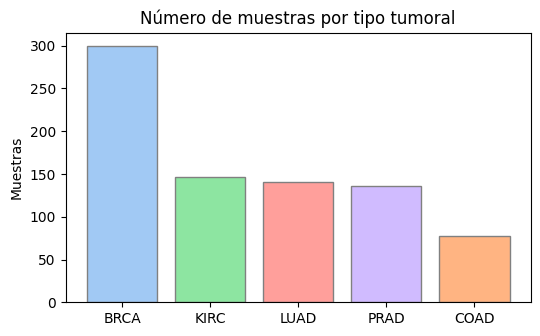

In [7]:
conteo = y.value_counts()
print(conteo)
print("Ratio clase mayor / clase menor:", round(conteo.max() / conteo.min(), 1))

plt.figure(figsize=(6, 3.5))
plt.bar(conteo.index, conteo.values, color=[COLORES[c] for c in conteo.index], edgecolor="gray")
plt.title("Número de muestras por tipo tumoral")
plt.ylabel("Muestras")
plt.savefig(FIG_DIR / "fig2_clases.png", dpi=DPI)
plt.show()

Las clases están desequilibradas: BRCA tiene 300 muestras (37,5 %) y COAD solo 78 (9,7 %). Por eso en la validación se usarán particiones estratificadas y, como métrica principal, el F1 macro: la media no ponderada del F1 calculado para cada clase, que da el mismo peso a las clases frecuentes y a las menos frecuentes. Las métricas de COAD, la clase menos representada, se interpretarán con más cautela.

### 3.2 PCA: datos centrados frente a datos estandarizados

La PCA se calcula con todas las muestras, solo para visualizar. Como la escala de los genes influye mucho en el resultado, se comparan dos versiones:

- **Datos centrados:** a cada gen se le resta su media. Los genes con más variabilidad pesan más.
- **Datos estandarizados:** cada gen se centra y se divide por su desviación estándar, de modo que todos los genes pesan lo mismo, también los que varían muy poco.

Este escalado exploratorio es independiente del que se aplicará después en los modelos (SVM y regresión logística), que formará parte del flujo de análisis y se ajustará dentro de cada partición de la validación.

Datos centrados: PC1 15.8 %, PC2 10.5 %, 10 primeras 55.8 %, 50 primeras 70.6 %


Datos estandarizados: PC1 10.5 %, PC2 8.8 %, 10 primeras 46.6 %, 50 primeras 63.7 %


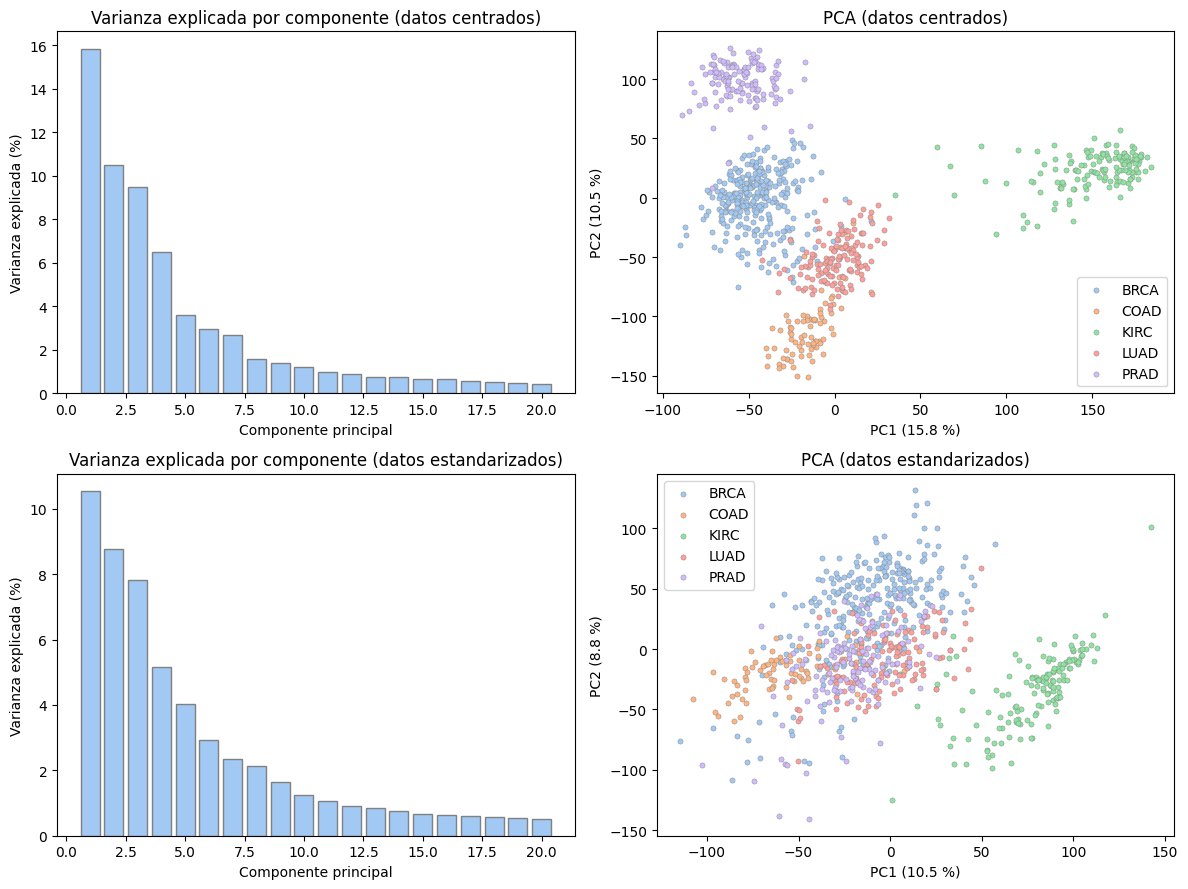

In [8]:
versiones = {
    "centrados": X_ok.values,  # la PCA de scikit-learn ya centra cada gen
    "estandarizados": StandardScaler().fit_transform(X_ok),
}

resultados_pca = {}
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
for fila, (nombre, matriz) in enumerate(versiones.items()):
    pca = PCA(n_components=50, random_state=SEED)
    coords = pca.fit_transform(matriz)
    var_exp = pca.explained_variance_ratio_ * 100
    resultados_pca[nombre] = coords
    print(f"Datos {nombre}: PC1 {var_exp[0]:.1f} %, PC2 {var_exp[1]:.1f} %, "
          f"10 primeras {var_exp[:10].sum():.1f} %, 50 primeras {var_exp.sum():.1f} %")

    # Varianza explicada por las 20 primeras componentes
    axs[fila, 0].bar(range(1, 21), var_exp[:20], color=COLOR_1_SERIE, edgecolor="gray")
    axs[fila, 0].set_title(f"Varianza explicada por componente (datos {nombre})")
    axs[fila, 0].set_xlabel("Componente principal")
    axs[fila, 0].set_ylabel("Varianza explicada (%)")

    # Muestras en el plano PC1-PC2
    for c in CLASES:
        m = (y == c).values
        axs[fila, 1].scatter(coords[m, 0], coords[m, 1], s=14, color=COLORES[c],
                             edgecolor="gray", linewidth=0.3, label=c)
    axs[fila, 1].set_title(f"PCA (datos {nombre})")
    axs[fila, 1].set_xlabel(f"PC1 ({var_exp[0]:.1f} %)")
    axs[fila, 1].set_ylabel(f"PC2 ({var_exp[1]:.1f} %)")
    axs[fila, 1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_pca.png", dpi=DPI)
plt.show()

**Resultado:**
- **Datos centrados:** PC1 y PC2 explican el 15,8 % y el 10,5 % de la varianza; las 10 primeras componentes, el 55,8 %, y las 50 primeras, el 70,6 %. En el plano PC1-PC2, KIRC queda a la derecha, PRAD arriba y COAD abajo; BRCA y LUAD quedan cerca y se solapan un poco.
- **Datos estandarizados:** la varianza está más repartida (PC1 10,5 %, PC2 8,8 %, 10 primeras 46,6 %, 50 primeras 63,7 %). Solo KIRC se separa; BRCA, COAD, LUAD y PRAD se mezclan en el centro.
- La representación depende bastante de la escala elegida.

**Representación principal: datos centrados.** Al estandarizar, cada gen pesa lo mismo, también los que apenas varían y cuya variación es sobre todo ruido. Al centrar, cada gen pesa según su variabilidad, que es la información que se quiere visualizar. Además, con los datos centrados las primeras componentes concentran más varianza. No se trata de que una opción sea correcta y la otra incorrecta: las dos se conservan en la figura para mostrar la sensibilidad a la escala.

In [9]:
PCA_PRINCIPAL = "centrados"  # representación principal (justificación en el texto anterior)
X_pca = resultados_pca[PCA_PRINCIPAL]

### 3.3 UMAP

El UMAP se calcula sobre las 50 primeras componentes de la PCA principal: es más rápido y reduce el ruido. Es una representación exploratoria: la separación visual entre grupos no mide el rendimiento de ningún clasificador.

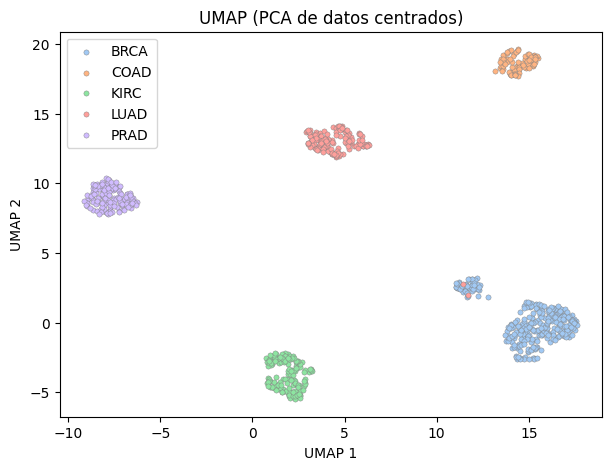

In [10]:
reductor = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=SEED)
X_umap = reductor.fit_transform(X_pca)

plt.figure(figsize=(7, 5))
for c in CLASES:
    m = (y == c).values
    plt.scatter(X_umap[m, 0], X_umap[m, 1], s=14, color=COLORES[c], edgecolor="gray", linewidth=0.3, label=c)
plt.title(f"UMAP (PCA de datos {PCA_PRINCIPAL})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.savefig(FIG_DIR / "fig4_umap.png", dpi=DPI)
plt.show()

**Resultado:** el UMAP sugiere cinco grupos separados, uno por tipo tumoral, lo que indica que los perfiles de expresión de las clases son distintos. Esta separación visual no demuestra que un clasificador vaya a distinguirlas ni mide su rendimiento.

BRCA aparece dividido en un grupo grande y otro pequeño, y dos muestras de LUAD quedan junto a ese grupo pequeño. Se anota como observación exploratoria de una posible heterogeneidad interna de BRCA, pero no se interpreta como evidencia de subtipos moleculares: haría falta información clínica adicional y una validación biológica basada en identificadores génicos fiables. Estas muestras se revisarán en el análisis de errores.

### 3.4 Mapa de calor de los 500 genes más variables

Como las clases tienen tamaños muy distintos (BRCA tiene casi cuatro veces más muestras que COAD), se dibujan dos versiones: con todas las muestras y con el mismo número de muestras de cada tipo (78, el tamaño de COAD, elegidas al azar). Así se puede ver si la intensidad de los bloques depende del tamaño de cada clase.

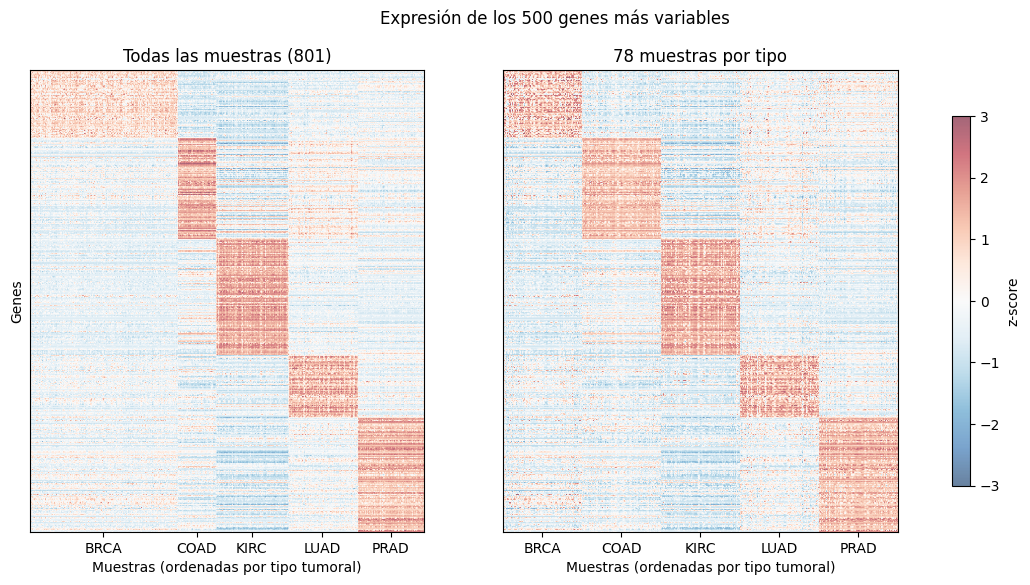

Genes del top 500 con la expresión media más alta en cada tipo tumoral:
      Todas las muestras  Muestras equilibradas
BRCA                  74                     74
COAD                 111                    110
KIRC                 125                    125
LUAD                  69                     67
PRAD                 121                    124


In [11]:
top500 = X_ok.var().nlargest(500).index

# Versión equilibrada: 78 muestras de cada tipo tumoral, elegidas al azar
n_min = y.value_counts().min()
equilibradas = y.groupby(y, group_keys=False).apply(lambda g: g.sample(n_min, random_state=SEED)).index

def matriz_heatmap(muestras):
    """z-score de cada gen (calculado con esas muestras) y muestras ordenadas por tipo tumoral."""
    orden = y[muestras].sort_values().index
    datos = X_ok.loc[orden, top500]
    return (datos - datos.mean()) / datos.std(), orden

completo, orden_completo = matriz_heatmap(y.index)
equilibrado, orden_equilibrado = matriz_heatmap(equilibradas)

# Los genes se ordenan según el tipo tumoral con la expresión media más alta (en la versión equilibrada)
clase_max = equilibrado.groupby(y[orden_equilibrado]).mean().idxmax()
orden_genes = clase_max.sort_values().index

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (datos, orden, titulo) in zip(axs, [(completo, orden_completo, "Todas las muestras (801)"),
                                            (equilibrado, orden_equilibrado, f"{n_min} muestras por tipo")]):
    # alpha < 1 suaviza los colores (tonos pastel)
    im = ax.imshow(datos[orden_genes].T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3, alpha=0.6)
    # Etiqueta de cada tipo tumoral en el centro de su bloque de muestras
    ax.set_xticks([np.where(y[orden] == c)[0].mean() for c in CLASES], CLASES)
    ax.set_yticks([])
    ax.set_title(titulo)
    ax.set_xlabel("Muestras (ordenadas por tipo tumoral)")
axs[0].set_ylabel("Genes")
fig.colorbar(im, ax=axs, label="z-score", shrink=0.8)
fig.suptitle("Expresión de los 500 genes más variables")
plt.savefig(FIG_DIR / "fig5_heatmap.png", dpi=DPI, bbox_inches="tight")
plt.show()

clase_max_completo = completo.groupby(y[orden_completo]).mean().idxmax()
print("Genes del top 500 con la expresión media más alta en cada tipo tumoral:")
print(pd.DataFrame({"Todas las muestras": clase_max_completo.value_counts(),
                    "Muestras equilibradas": clase_max.value_counts()}).reindex(CLASES))

**Resultado:**
- Con las dos versiones, cada tipo tumoral tiene un bloque de genes que se expresan más en esa clase que en el resto (zonas rojas), y KIRC tiene además genes menos expresados que en las otras clases (zonas azules).
- Con todas las muestras, el bloque de BRCA parece mucho menos marcado. Con 78 muestras de cada tipo es tan claro como el de las otras clases, y el número de genes asignados a cada tipo apenas cambia (74 en BRCA en las dos versiones). Por tanto, la menor intensidad de BRCA se debe sobre todo a su tamaño: al tener casi cuatro veces más muestras, pesa más en la media de cada gen y su z-score queda más cerca de 0.
- El mapa de calor se utiliza únicamente como representación exploratoria. La intensidad de los patrones puede estar influida por el tamaño desigual de las clases y no se interpreta como evidencia independiente de subtipos moleculares ni de capacidad predictiva.
- Las variables tienen identificadores genéricos (`gene_X`). Su correspondencia con los genes de TCGA se ha reconstruido y verificado con `correspondencia_genes/correspondencia_genes.py` (tabla en `correspondencia_genes/resultados/correspondencia_genes.csv`; riesgo R3 de la PEC1). La interpretación biológica de los genes se abordará en la fase de explicabilidad.

## 4. Conclusión

Los datos tienen buena calidad: no hay valores faltantes ni duplicados y no hace falta eliminar muestras. Solo hay que quitar los 267 genes sin variación, cosa que se hará dentro del flujo de análisis. Hay 20 muestras atípicas en la expresión media o en el porcentaje de ceros, que se conservan y se revisarán en el análisis de errores. Las clases están desequilibradas, lo que justifica la validación estratificada y el uso del F1 macro.

La PCA de datos centrados, el UMAP y el mapa de calor sugieren que los cinco tipos tumorales tienen perfiles de expresión diferentes. Por eso es esperable que varios modelos obtengan un rendimiento muy alto, y la comparación se apoyará también en el número de genes necesarios, la estabilidad de las variables, la explicabilidad y el coste computacional.